In [1]:
import sys
sys.path.append("./lib")
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'  
import plotlib as plib 
%matplotlib inline

xlabel= "$f_{sky}$" #label for the different cases 
cases = ["0.5","0.6", "0.7","0.8","0.9","0.97"] #different scenarios you want to plot on x axis
subcases = ["o0", "1bts", "adapt."] #different scenarios you want to plot for each point of x
colors = ["blue", "darkorange", "red"]
kw_save= "fsky_vs_fittingscheme"
path = "./"

mom = ['Aw1b', 'w1bw1b', 'Aw1t', 'w1bw1t', 'w1tw1t', 'Asw1bs', 'w1bsw1bs', 'Asw1b', 'Asw1t', 'Aw1bs', 'w1bw1bs', 'w1tw1bs']
def nfixmom(res):
    total = 0   
    zero_counts_mean = {}
    for k in mom:
        arr = np.asarray(res[k])
        total += len(arr[:,1])
        means = np.mean(arr, axis=1)
        zero_counts_mean[k] = np.sum(means == 0)
    total_zero_means = total-sum(zero_counts_mean.values())
    return total_zero_means

#load the results:

res_c0sc0 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_maskGWD_ds_o%s_fix%s.npy'%(1,1,0.5,'0',0),allow_pickle=True).item()
res_c0sc1 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_maskGWD_ds_o%s_fix%s.npy'%(1,1,0.5,'1bts',1),allow_pickle=True).item()
res_c0sc2 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_maskGWD_ds_o%s_fix%s_adaptative.npy'%(1,1,0.5,'1bts',1),allow_pickle=True).item()

res_c1sc0 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s.npy'%(1,1,0.6,'0',0),allow_pickle=True).item()
res_c1sc1 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s.npy'%(1,1,0.6,'1bts',1),allow_pickle=True).item()
res_c1sc2 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s_adaptative.npy'%(1,1,0.6,'1bts',1),allow_pickle=True).item()

res_c2sc0 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s.npy'%(1,1,0.7,'0',0),allow_pickle=True).item()
res_c2sc1 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s.npy'%(1,1,0.7,'1bts',1),allow_pickle=True).item()
res_c2sc2 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s_adaptative.npy'%(1,1,0.7,'1bts',1),allow_pickle=True).item()

res_c3sc0 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s.npy'%(1,1,0.8,'0',0),allow_pickle=True).item()
res_c3sc1 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s.npy'%(1,1,0.8,'1bts',1),allow_pickle=True).item()
res_c3sc2 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s_adaptative.npy'%(1,1,0.8,'1bts',1),allow_pickle=True).item()

res_c4sc0 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s.npy'%(1,1,0.9,'0',0),allow_pickle=True).item()
res_c4sc1 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s.npy'%(1,1,0.9,'1bts',1),allow_pickle=True).item()
res_c4sc2 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s_adaptative.npy'%(1,1,0.9,'1bts',1),allow_pickle=True).item()

res_c5sc0 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s.npy'%(1,1,0.97,'0',0),allow_pickle=True).item()
res_c5sc1 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s.npy'%(1,1,0.97,'1bts',1),allow_pickle=True).item()
res_c5sc2 = np.load(path + '/best_fits/results_d%ss%s_%s_Nmt-fg_ds_o%s_fix%s_adaptative.npy'%(1,1,0.97,'1bts',1),allow_pickle=True).item()

res_list = [
    [res_c0sc0, res_c1sc0, res_c2sc0, res_c3sc0, res_c4sc0, res_c5sc0], # all cases ordered for subcase 0
    [res_c0sc1, res_c1sc1, res_c2sc1, res_c3sc1, res_c4sc1, res_c5sc1], # all cases ordered for subcase 1
    [res_c0sc2, res_c1sc2, res_c2sc2, res_c3sc2, res_c4sc2, res_c5sc2]  # all cases ordered for subcase 2
    # up to subcase N !
]

# Initialisation des tableaux
r_all, sigma_r_all = [], []
X_all, sigma_X_all = [], []

# Boucle sur chaque ensemble de résolutions
for res_group in res_list:
    r_group, sigma_r_group = [], []
    X_group, sigma_X_group = [], []
    for res in res_group:
        rmean, rstd = plib.getr_analytical(res, Nmin=0, Nmax=20)
        Xmean, Xstd = plib.getX2_analytical(res, Nmin=0, Nmax=20)
        r_group.append(rmean)
        sigma_r_group.append(rstd)
        X_group.append(Xmean)
        sigma_X_group.append(Xstd)
    r_all.append(np.array(r_group))
    sigma_r_all.append(np.array(sigma_r_group))
    X_all.append(np.array(X_group))
    sigma_X_all.append(np.array(sigma_X_group))

# Paramètres du plot
offset = 0.05
x = np.arange(len(cases))


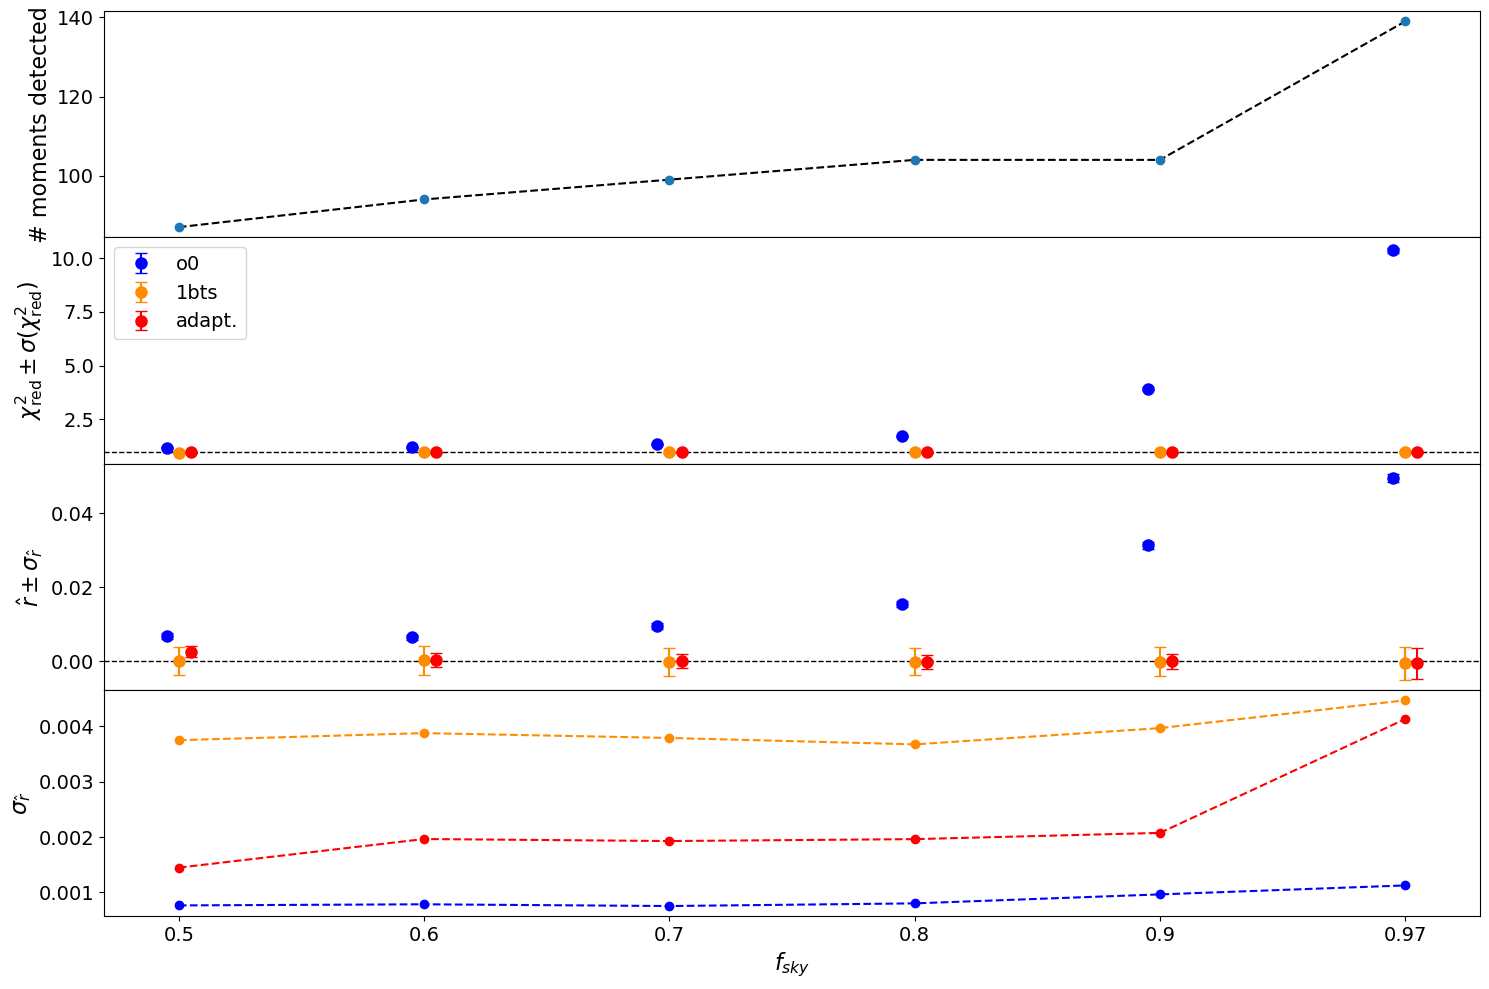

In [6]:
fig, (ax1, ax2,ax3,ax4) = plt.subplots(4, 1, figsize=(15, 10), sharex=True, gridspec_kw={'hspace': 0.0})
ax2.axhline(1, linestyle="--", color="k", linewidth=1)
ax3.axhline(0, linestyle="--", color="k", linewidth=1)

# Plot des erreurs
for i in range(len(res_list)):
    ax2.errorbar(x + (i-1)*offset, X_all[i], yerr=sigma_X_all[i], fmt="o", label=subcases[i],
                 c=colors[i], markersize=8, capsize=4)
    ax3.errorbar(x + (i-1)*offset, r_all[i], yerr=sigma_r_all[i], fmt="o", label=subcases[i],
                 c=colors[i], markersize=8, capsize=4)
    ax4.plot(x, sigma_r_all[i], label=subcases[i], c=colors[i],linestyle='--')
    ax4.plot(x, sigma_r_all[i], marker="o", label=subcases[i],linestyle='',c=colors[i])

ax1.plot(x, [nfixmom(res) for res in res_list[i]], label=subcases[i], c='k',linestyle='--')
ax1.plot(x, [nfixmom(res) for res in res_list[i]], marker="o", label=subcases[i],linestyle='')
ax1.set_ylabel(r"# moments detected", fontsize=16)
ax1.tick_params(labelsize=14)
ax2.set_ylabel(r"$\chi^2_{\rm red} \pm \sigma(\chi^2_{\rm red})$", fontsize=16)
ax2.legend(fontsize=14)
ax2.tick_params(labelsize=14)
ax3.set_xticks(x)
ax3.set_xticklabels(cases, fontsize=14, rotation=45, ha="right")
ax3.set_ylabel(r"$\hat{r}\pm \sigma_{\hat{r}}$", fontsize=16)
ax3.tick_params(labelsize=14)
ax4.set_ylabel(r"$\sigma_{\hat{r}}$", fontsize=16)
ax4.tick_params(labelsize=14)
plt.xlabel("%s" % xlabel, fontsize=16)
plt.tight_layout()
plt.savefig(f"./pdf_plots/sigma_r_{kw_save}.pdf", bbox_inches="tight")
plt.show()